# Instacart Tekrar Satın Alma Tahmini

## Projenin Amacı

Bu projede, Instacart müşterilerinin geçmiş sipariş davranışları analiz edilerek bir müşterinin daha önce satın aldığı bir ürünü bir sonraki siparişinde tekrar satın alıp almayacağının tahmin edilmesi amaçlanmaktadır.

Problem bir **ikili sınıflandırma (Binary Classification)** problemidir.

Hedef değişken:

- **0:** Ürün bir sonraki siparişte tekrar satın alınmadı.
- **1:** Ürün bir sonraki siparişte tekrar satın alındı.

Ana model olarak **Lojistik Regresyon (Logistic Regression)** kullanılacaktır.

Model performansını karşılaştırmak amacıyla ayrıca **Random Forest (Rastgele Orman)** modeli uygulanacaktır.

Model değerlendirmesinde yalnızca doğruluk oranı kullanılmayacak; hedef değişkenin dengesiz yapısı nedeniyle **Precision (Kesinlik), Recall (Duyarlılık), F1 Score (F1 Skoru), ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) ve PR-AUC (Precision-Recall – Area Under the Curve)** metrikleri birlikte değerlendirilecektir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


## Kullanılan Temel Kütüphaneler

Bu projede veri analizi ve görselleştirme işlemleri için temel Python kütüphaneleri kullanılmıştır.

- **Pandas:** Verilerin tablo yapısında işlenmesi ve analiz edilmesi için kullanılmıştır.
- **NumPy:** Sayısal işlemler ve veri dönüşümleri için kullanılmıştır.
- **Matplotlib:** Keşifsel veri analizi ve model sonuçlarının görselleştirilmesi için kullanılmıştır.

Makine öğrenmesi aşamasında ayrıca **Scikit-learn** kütüphanesinden yararlanılacaktır.

In [2]:
from google.colab import auth

auth.authenticate_user()

print("Google hesabı başarıyla doğrulandı.")

Google hesabı başarıyla doğrulandı.


## Google Cloud Kimlik Doğrulama

Veriler Google BigQuery üzerinde tutulduğu için Google Colab ortamının Google Cloud hesabına erişebilmesi gerekmektedir.

Bu adımda `google.colab.auth` modülü kullanılarak kullanıcı kimlik doğrulaması gerçekleştirilmiştir.

Kimlik doğrulama sayesinde Colab üzerinden BigQuery içerisinde bulunan veri setlerine ve tablolara güvenli şekilde erişilebilmektedir.

In [3]:
from google.cloud import bigquery

project_id = "project-84485539-b01a-418a-932"

client = bigquery.Client(project=project_id)

print("BigQuery bağlantısı başarıyla kuruldu.")

BigQuery bağlantısı başarıyla kuruldu.


## BigQuery Bağlantısının Oluşturulması

Google hesabı doğrulandıktan sonra `google.cloud.bigquery` kütüphanesi kullanılarak BigQuery istemcisi oluşturulmuştur.

Projede kullanılan Google Cloud proje kimliği:

`project-84485539-b01a-418a-932`

Bu bağlantı sayesinde BigQuery üzerinde hazırlanan analiz tabloları doğrudan Python ortamına aktarılabilmektedir.

In [4]:
query = """
SELECT *
FROM `project-84485539-b01a-418a-932.Instacart_Analytics.customer_product_features`
"""

model_df = client.query(query).to_dataframe()

print("Veri başarıyla yüklendi.")
print("Veri boyutu:", model_df.shape)

model_df.head()

Veri başarıyla yüklendi.
Veri boyutu: (8474661, 14)


,user_id,product_id,product_purchase_count,product_order_count,first_product_order,last_product_order,product_order_span,avg_add_to_cart_order,avg_product_qty_per_order,total_prior_orders,avg_days_between_orders,user_product_order_rate,orders_since_last_purchase,will_reorder
0,112678,45231,1,1,1,1,0,6.0,1.0,99,3.53,0.0101,98,0
1,27907,13984,1,1,1,1,0,4.0,1.0,99,3.54,0.0101,98,0
2,127890,23594,1,1,1,1,0,6.0,1.0,99,2.33,0.0101,98,0
3,47666,6606,1,1,1,1,0,10.0,1.0,99,3.23,0.0101,98,0
4,52136,26764,1,1,1,1,0,18.0,1.0,99,1.99,0.0101,98,0


## Modelleme Verisinin BigQuery'den Alınması

Makine öğrenmesi modelinde kullanılacak veri, BigQuery üzerinde daha önce hazırlanmış olan `customer_product_features` tablosundan alınmıştır.

Bu tabloda her satır bir **müşteri-ürün çiftini** temsil etmektedir.

Modelde kullanılacak değişkenler müşterinin geçmiş sipariş davranışlarından üretilmiştir. Hedef değişken olan `will_reorder` ise müşterinin ilgili ürünü bir sonraki siparişinde tekrar satın alıp almadığını göstermektedir.

- **will_reorder = 0:** Ürün tekrar satın alınmadı.
- **will_reorder = 1:** Ürün tekrar satın alındı.

Veri doğrudan BigQuery üzerinden Python ortamına aktarılmıştır.

In [5]:
print("Veri tipi ve kolon bilgileri:")
print()
model_df.info()

print("\nEksik değer sayıları:")
print(model_df.isnull().sum())

Veri tipi ve kolon bilgileri:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8474661 entries, 0 to 8474660
Data columns (total 14 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   user_id                     Int64  
 1   product_id                  Int64  
 2   product_purchase_count      Int64  
 3   product_order_count         Int64  
 4   first_product_order         Int64  
 5   last_product_order          Int64  
 6   product_order_span          Int64  
 7   avg_add_to_cart_order       float64
 8   avg_product_qty_per_order   float64
 9   total_prior_orders          Int64  
 10  avg_days_between_orders     float64
 11  user_product_order_rate     float64
 12  orders_since_last_purchase  Int64  
 13  will_reorder                Int64  
dtypes: Int64(10), float64(4)
memory usage: 986.0 MB

Eksik değer sayıları:
user_id                       0
product_id                    0
product_purchase_count        0
product_order_count         

### Kontrol Sonucu

Veri setinde eksik değer bulunmamıştır. Bu nedenle modelleme öncesinde eksik veri doldurma veya satır silme işlemi uygulanmasına ihtiyaç duyulmamıştır.

Sayısal değişkenlerin veri tipleri de modelleme için uygun yapıdadır.

In [6]:
target_counts = model_df["will_reorder"].value_counts()
target_ratio = model_df["will_reorder"].value_counts(normalize=True) * 100

print("Hedef değişken dağılımı:")
print(target_counts)

print("\nHedef değişken yüzdeleri:")
print(target_ratio.round(2))

Hedef değişken dağılımı:
will_reorder
0    7645837
1     828824
Name: count, dtype: Int64

Hedef değişken yüzdeleri:
will_reorder
0    90.22
1     9.78
Name: proportion, dtype: Float64


## Hedef Değişkenin Dağılımı

Modelin hedef değişkeni `will_reorder` değişkenidir.

- **0:** Ürün bir sonraki siparişte tekrar satın alınmadı.
- **1:** Ürün bir sonraki siparişte tekrar satın alındı.

Hedef değişkenin dağılımı incelendiğinde:

- Tekrar satın alınmayan ürünlerin oranı **%90,22**
- Tekrar satın alınan ürünlerin oranı **%9,78**

olarak bulunmuştur.

Bu sonuç, hedef değişkende belirgin bir **sınıf dengesizliği (Class Imbalance)** olduğunu göstermektedir.

Bu nedenle model performansı değerlendirilirken yalnızca **Accuracy (Doğruluk)** metriğine bakmak yeterli olmayacaktır. İlerleyen aşamalarda **Precision (Kesinlik), Recall (Duyarlılık), F1 Score (F1 Skoru), ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) ve PR-AUC (Precision-Recall – Area Under the Curve)** metrikleri de birlikte değerlendirilecektir.

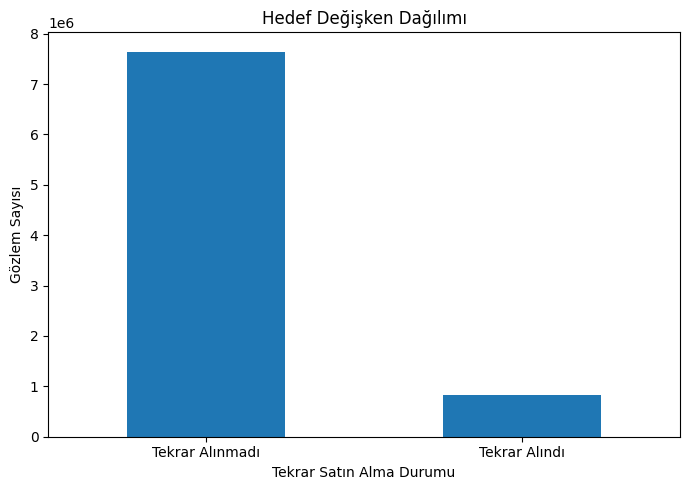

In [7]:
plt.figure(figsize=(7, 5))

target_counts.sort_index().plot(kind="bar")

plt.title("Hedef Değişken Dağılımı")
plt.xlabel("Tekrar Satın Alma Durumu")
plt.ylabel("Gözlem Sayısı")

plt.xticks(
    [0, 1],
    ["Tekrar Alınmadı", "Tekrar Alındı"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Grafik Yorumu

Hedef değişken dağılımı incelendiğinde, tekrar satın alınmayan ürünlerin sayısının tekrar satın alınan ürünlere göre belirgin şekilde daha yüksek olduğu görülmektedir.

Bu durum, veri setinde **sınıf dengesizliği (Class Imbalance)** bulunduğunu görsel olarak da doğrulamaktadır.

Modelleme aşamasında bu dengesizlik dikkate alınacak ve model performansı yalnızca **Accuracy (Doğruluk)** üzerinden değerlendirilmemeyecektir.

In [8]:
model_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,8474661.0,102980.038085,59458.926633,1.0,51620.0,102590.0,154607.0,206209.0
product_id,8474661.0,25511.71188,14225.135822,1.0,13292.0,25640.0,38156.0,49688.0
product_purchase_count,8474661.0,2.435731,3.549315,1.0,1.0,1.0,2.0,99.0
product_order_count,8474661.0,2.435731,3.549315,1.0,1.0,1.0,2.0,99.0
first_product_order,8474661.0,10.694211,13.45809,1.0,2.0,6.0,13.0,99.0
last_product_order,8474661.0,15.868151,17.272371,1.0,4.0,9.0,21.0,99.0
product_order_span,8474661.0,5.17394,11.665889,0.0,0.0,0.0,5.0,98.0
avg_add_to_cart_order,8474661.0,9.210232,6.991181,1.0,4.0,7.5,12.0,145.0
avg_product_qty_per_order,8474661.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
total_prior_orders,8474661.0,25.389131,22.238935,3.0,9.0,18.0,35.0,99.0


## Sayısal Değişkenlerin Özet İstatistikleri

Veri setindeki sayısal değişkenlerin dağılımını genel olarak incelemek amacıyla özet istatistikler hesaplanmıştır.

Öne çıkan bazı bulgular:

- Bir müşteri-ürün çiftinde ürünün ortalama satın alınma sayısı yaklaşık **2,44**'tür.
- Müşterilerin geçmiş sipariş sayısı ortalama **25,39**, medyan ise **18**'dir.
- Siparişler arasındaki ortalama süre yaklaşık **12,68 gün**'dür.
- Bir ürünün müşterinin geçmiş siparişlerinde bulunma oranı (`user_product_order_rate`) ortalama yaklaşık **%15,4**'tür.
- Ürünün son satın alınmasından bu yana geçen sipariş sayısı (`orders_since_last_purchase`) ortalama **9,52**, medyan ise **4**'tür.
- `avg_product_qty_per_order` değişkeninin tüm gözlemlerde **1** olduğu görülmektedir. Bu değişken varyans içermediği için modelleme aşamasında açıklayıcı katkı sağlaması beklenmemektedir.

Bazı değişkenlerde ortalama ile medyan arasında belirgin fark bulunması, dağılımların simetrik olmadığını ve uç değerlerin bulunabileceğini göstermektedir.

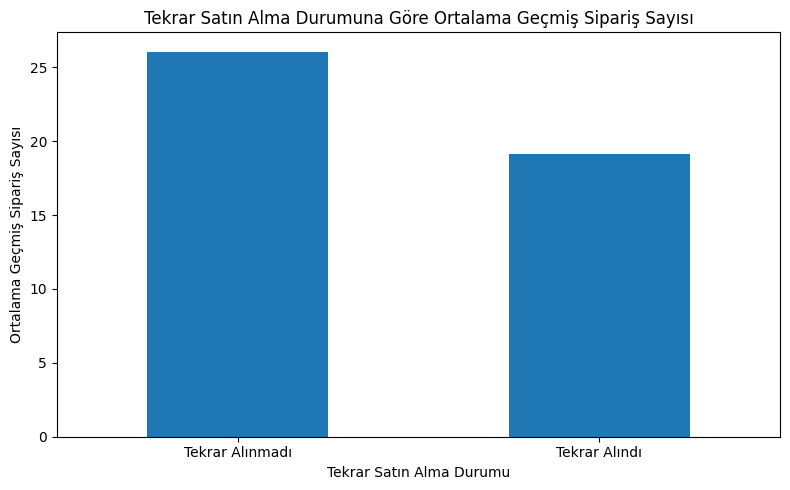

In [9]:
plt.figure(figsize=(8, 5))

model_df.groupby("will_reorder")["total_prior_orders"].mean().plot(kind="bar")

plt.title("Tekrar Satın Alma Durumuna Göre Ortalama Geçmiş Sipariş Sayısı")
plt.xlabel("Tekrar Satın Alma Durumu")
plt.ylabel("Ortalama Geçmiş Sipariş Sayısı")

plt.xticks(
    [0, 1],
    ["Tekrar Alınmadı", "Tekrar Alındı"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Grafik Yorumu

Tekrar satın alma durumuna göre müşterilerin geçmiş sipariş sayıları karşılaştırıldığında, tekrar satın alınmayan müşteri-ürün çiftlerinde ortalama geçmiş sipariş sayısının daha yüksek olduğu görülmektedir.

Bu sonuç, müşterinin toplam sipariş sayısının tek başına tekrar satın alma davranışını açıklamak için yeterli olmadığını göstermektedir.

Tekrar satın alma davranışında müşterinin ilgili ürünü geçmişte ne sıklıkla satın aldığı ve ürünü son satın almasından bu yana kaç sipariş geçtiği gibi **müşteri-ürün ilişkisini doğrudan temsil eden değişkenlerin** daha açıklayıcı olması beklenmektedir.

Bu grafik yalnızca değişkenler arasındaki gözlemsel ilişkiyi göstermektedir ve nedensellik ifade etmemektedir.

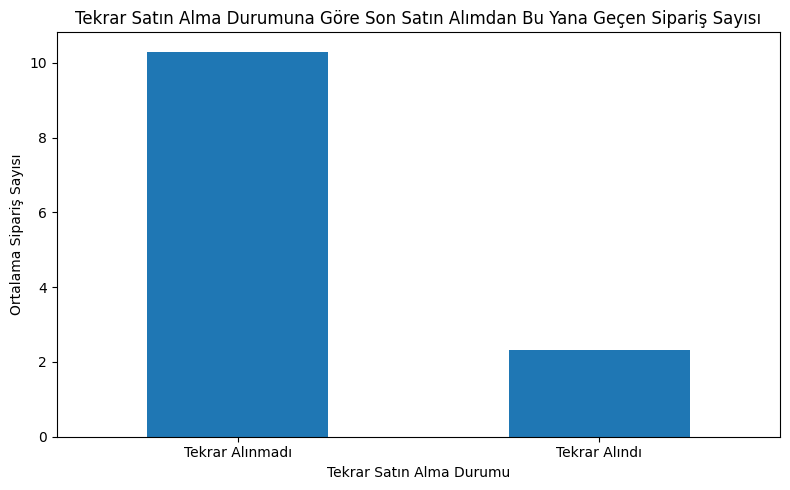

In [10]:
plt.figure(figsize=(8, 5))

model_df.groupby("will_reorder")["orders_since_last_purchase"].mean().plot(kind="bar")

plt.title("Tekrar Satın Alma Durumuna Göre Son Satın Alımdan Bu Yana Geçen Sipariş Sayısı")
plt.xlabel("Tekrar Satın Alma Durumu")
plt.ylabel("Ortalama Sipariş Sayısı")

plt.xticks(
    [0, 1],
    ["Tekrar Alınmadı", "Tekrar Alındı"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Grafik Yorumu

Tekrar satın alma durumuna göre ürünün son satın alınmasından bu yana geçen sipariş sayısı incelendiğinde belirgin bir fark görülmektedir.

Tekrar satın alınan ürünlerde, son satın alımdan bu yana geçen ortalama sipariş sayısı oldukça düşüktür. Buna karşılık tekrar satın alınmayan ürünlerde bu süre belirgin şekilde daha yüksektir.

Bu sonuç, müşterinin bir ürünü ne kadar yakın zamanda satın aldığı bilgisinin tekrar satın alma tahmininde önemli bir açıklayıcı değişken olabileceğini göstermektedir.

Başka bir ifadeyle, bir ürün müşterinin yakın dönem siparişlerinde yer alıyorsa tekrar satın alınma eğilimi daha yüksek görünmektedir.

Bu ilişki gözlemseldir ve tek başına nedensellik ifade etmemektedir.

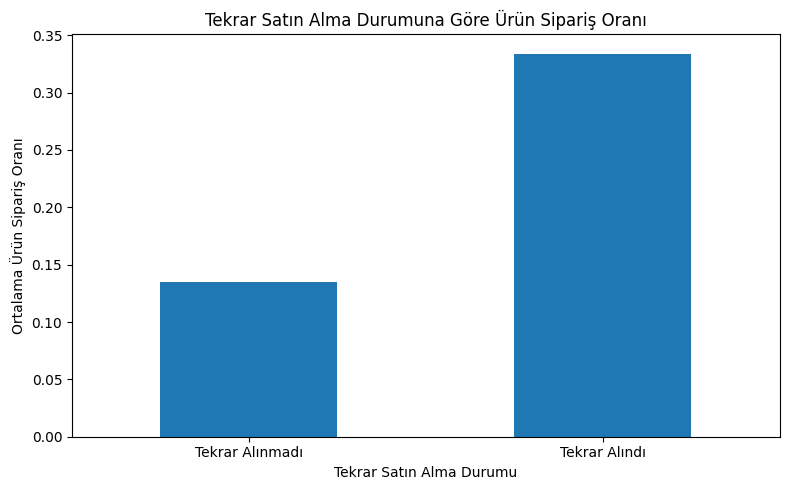

In [11]:
plt.figure(figsize=(8, 5))

model_df.groupby("will_reorder")["user_product_order_rate"].mean().plot(kind="bar")

plt.title("Tekrar Satın Alma Durumuna Göre Ürün Sipariş Oranı")
plt.xlabel("Tekrar Satın Alma Durumu")
plt.ylabel("Ortalama Ürün Sipariş Oranı")

plt.xticks(
    [0, 1],
    ["Tekrar Alınmadı", "Tekrar Alındı"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Grafik Yorumu

Müşterinin geçmiş siparişlerinde ilgili ürüne ne sıklıkla yer verdiğini gösteren `user_product_order_rate` değişkeni incelendiğinde, tekrar satın alınan ürünlerde bu oranın belirgin şekilde daha yüksek olduğu görülmektedir.

Tekrar satın alınmayan ürünlerde ortalama ürün sipariş oranı yaklaşık **%13** seviyesindeyken, tekrar satın alınan ürünlerde bu oran yaklaşık **%33** seviyesindedir.

Bu sonuç, müşterinin geçmişte bir ürünü düzenli olarak satın almasının, gelecekte aynı ürünü tekrar satın alma olasılığı açısından önemli bir gösterge olabileceğini düşündürmektedir.

Bu ilişki gözlemseldir ve tek başına nedensellik ifade etmemektedir.

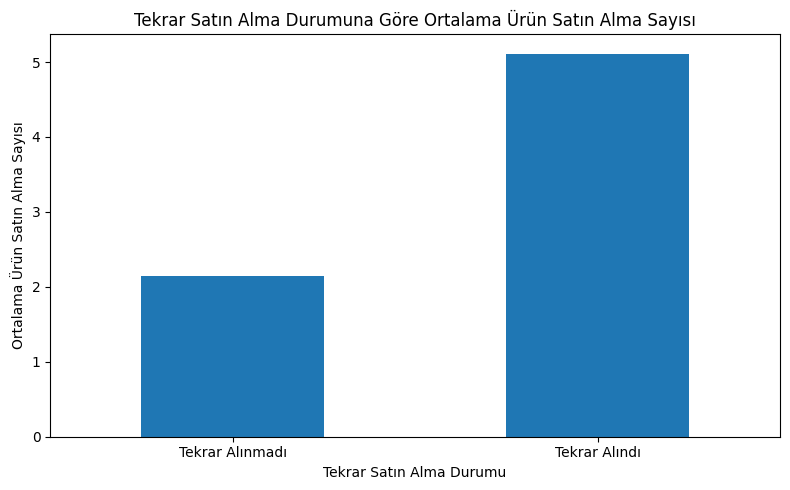

In [12]:
plt.figure(figsize=(8, 5))

model_df.groupby("will_reorder")["product_purchase_count"].mean().plot(kind="bar")

plt.title("Tekrar Satın Alma Durumuna Göre Ortalama Ürün Satın Alma Sayısı")
plt.xlabel("Tekrar Satın Alma Durumu")
plt.ylabel("Ortalama Ürün Satın Alma Sayısı")

plt.xticks(
    [0, 1],
    ["Tekrar Alınmadı", "Tekrar Alındı"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Grafik Yorumu

Tekrar satın alma durumuna göre ürünün geçmişte kaç kez satın alındığı incelendiğinde belirgin bir fark görülmektedir.

Tekrar satın alınmayan ürünlerde ortalama satın alma sayısı yaklaşık **2,1** iken, tekrar satın alınan ürünlerde bu değer yaklaşık **5,1** seviyesindedir.

Bu sonuç, müşterinin bir ürünü geçmişte daha sık satın almasının, aynı ürünü gelecekte tekrar satın alma olasılığı açısından önemli bir gösterge olabileceğini düşündürmektedir.

Bu ilişki gözlemseldir ve tek başına nedensellik ifade etmemektedir.

In [13]:
correlation_with_target = (
    model_df.corr(numeric_only=True)["will_reorder"]
    .sort_values(ascending=False)
)

correlation_with_target

,will_reorder
will_reorder,1.000000
user_product_order_rate,0.360553
product_purchase_count,0.248376
product_order_count,0.248376
product_order_span,0.115969
avg_days_between_orders,0.071582
last_product_order,0.018061
product_id,0.002786
user_id,-0.000429
avg_add_to_cart_order,-0.042597


## Hedef Değişken ile Korelasyon Analizi

Sayısal değişkenlerin hedef değişken `will_reorder` ile olan doğrusal ilişkileri korelasyon analizi ile incelenmiştir.

Öne çıkan sonuçlar:

- `user_product_order_rate` değişkeni ile tekrar satın alma arasında yaklaşık **0,36** seviyesinde pozitif ilişki bulunmaktadır.
- `product_purchase_count` ve `product_order_count` değişkenleri yaklaşık **0,25** korelasyon ile tekrar satın alma davranışıyla pozitif ilişki göstermektedir.
- `orders_since_last_purchase` değişkeni yaklaşık **-0,18** korelasyon ile en belirgin negatif ilişkiye sahiptir.

Bu sonuçlar, müşterinin bir ürünü geçmiş siparişlerinde ne kadar düzenli ve sık satın aldığının tekrar satın alma olasılığı açısından önemli olabileceğini göstermektedir.

Buna karşılık ürünün son satın alınmasından bu yana geçen sipariş sayısı arttıkça tekrar satın alma eğiliminin azaldığı görülmektedir.

Korelasyon değerleri değişkenler arasındaki doğrusal ilişkiyi göstermektedir ve tek başına nedensellik ifade etmemektedir.

In [14]:
feature_columns = [
    "product_purchase_count",
    "product_order_count",
    "first_product_order",
    "last_product_order",
    "product_order_span",
    "avg_add_to_cart_order",
    "total_prior_orders",
    "avg_days_between_orders",
    "user_product_order_rate",
    "orders_since_last_purchase"
]

correlation_matrix = model_df[feature_columns].corr()

correlation_matrix.round(2)

,product_purchase_count,product_order_count,first_product_order,last_product_order,product_order_span,avg_add_to_cart_order,total_prior_orders,avg_days_between_orders,user_product_order_rate,orders_since_last_purchase
product_purchase_count,1.00,1.00,-0.10,0.39,0.70,-0.09,0.24,-0.17,0.47,-0.11
product_order_count,1.00,1.00,-0.10,0.39,0.70,-0.09,0.24,-0.17,0.47,-0.11
first_product_order,-0.10,-0.10,1.00,0.74,-0.06,0.04,0.63,-0.43,-0.40,0.09
last_product_order,0.39,0.39,0.74,1.00,0.63,-0.00,0.80,-0.54,-0.21,0.04
product_order_span,0.70,0.70,-0.06,0.63,1.00,-0.05,0.46,-0.30,0.15,-0.05
avg_add_to_cart_order,-0.09,-0.09,0.04,-0.00,-0.05,1.00,0.00,0.00,-0.12,0.01
total_prior_orders,0.24,0.24,0.63,0.80,0.46,0.00,1.00,-0.68,-0.40,0.63
avg_days_between_orders,-0.17,-0.17,-0.43,-0.54,-0.30,0.00,-0.68,1.00,0.35,-0.43
user_product_order_rate,0.47,0.47,-0.40,-0.21,0.15,-0.12,-0.40,0.35,1.00,-0.40
orders_since_last_purchase,-0.11,-0.11,0.09,0.04,-0.05,0.01,0.63,-0.43,-0.40,1.00


## Bağımsız Değişkenler Arası Korelasyon Analizi

Lojistik Regresyon (Logistic Regression) modelinde kullanılacak bağımsız değişkenlerin birbirleriyle olan ilişkileri incelenmiştir.

Bu kontrolün amacı, aynı veya çok benzer bilgiyi taşıyan değişkenleri belirlemek ve **çoklu doğrusal bağlantı (Multicollinearity)** riskini azaltmaktır.

Analiz sonucunda öne çıkan ilişkiler:

- `product_purchase_count` ile `product_order_count` arasındaki korelasyon **1,00** olarak bulunmuştur. Bu iki değişken mevcut veri setinde aynı bilgiyi taşımaktadır.
- `last_product_order` ile `total_prior_orders` arasında **0,80** seviyesinde yüksek pozitif ilişki bulunmaktadır.
- `first_product_order` ile `last_product_order` arasında yaklaşık **0,74** korelasyon bulunmaktadır.
- `product_purchase_count` ile `product_order_span` arasında yaklaşık **0,70** korelasyon bulunmaktadır.

Özellikle `product_purchase_count` ve `product_order_count` değişkenlerinin tamamen aynı hareket etmesi nedeniyle, modelleme aşamasında bu iki değişkenden yalnızca birinin kullanılması daha uygun olacaktır.

Bu nedenle `product_purchase_count` modelde tutulacak, `product_order_count` ise model değişkenleri arasından çıkarılacaktır.

In [15]:
features = [
    "product_purchase_count",
    "first_product_order",
    "last_product_order",
    "product_order_span",
    "avg_add_to_cart_order",
    "total_prior_orders",
    "avg_days_between_orders",
    "user_product_order_rate",
    "orders_since_last_purchase"
]

X = model_df[features]
y = model_df["will_reorder"]

print("Bağımsız değişken sayısı:", X.shape[1])
print("Bağımsız değişkenler:")
print(features)

print("\nX boyutu:", X.shape)
print("y boyutu:", y.shape)

Bağımsız değişken sayısı: 9
Bağımsız değişkenler:
['product_purchase_count', 'first_product_order', 'last_product_order', 'product_order_span', 'avg_add_to_cart_order', 'total_prior_orders', 'avg_days_between_orders', 'user_product_order_rate', 'orders_since_last_purchase']

X boyutu: (8474661, 9)
y boyutu: (8474661,)


## Modelde Kullanılacak Değişkenlerin Belirlenmesi

Korelasyon analizi ve değişkenlerin yapısı dikkate alınarak modelde kullanılacak bağımsız değişkenler belirlenmiştir.

Modelde toplam **9 bağımsız değişken** kullanılacaktır.

Model dışında bırakılan değişkenler:

- `product_order_count`: `product_purchase_count` ile korelasyonu **1,00** olduğu için çıkarılmıştır.
- `avg_product_qty_per_order`: Tüm gözlemlerde aynı değeri aldığı ve varyans içermediği için çıkarılmıştır.
- `user_id` ve `product_id`: Kimlik değişkenleri oldukları için model girdisi olarak kullanılmamıştır.

Hedef değişken:

- `will_reorder`

Bağımsız değişkenler `X`, hedef değişken ise `y` olarak tanımlanmıştır.

In [16]:
from sklearn.model_selection import train_test_split

unique_users = np.sort(model_df["user_id"].unique())

train_users, test_users = train_test_split(
    unique_users,
    test_size=0.20,
    random_state=42
)

train_df = model_df[model_df["user_id"].isin(train_users)].copy()
test_df = model_df[model_df["user_id"].isin(test_users)].copy()

print("Eğitim kullanıcı sayısı:", train_df["user_id"].nunique())
print("Test kullanıcı sayısı:", test_df["user_id"].nunique())

print("\nEğitim veri boyutu:", train_df.shape)
print("Test veri boyutu:", test_df.shape)

print("\nEğitim hedef dağılımı:")
print(train_df["will_reorder"].value_counts(normalize=True).round(4))

print("\nTest hedef dağılımı:")
print(test_df["will_reorder"].value_counts(normalize=True).round(4))

Eğitim kullanıcı sayısı: 104967
Test kullanıcı sayısı: 26242

Eğitim veri boyutu: (6777721, 14)
Test veri boyutu: (1696940, 14)

Eğitim hedef dağılımı:
will_reorder
0    0.9021
1    0.0979
Name: proportion, dtype: Float64

Test hedef dağılımı:
will_reorder
0    0.9027
1    0.0973
Name: proportion, dtype: Float64


## Eğitim ve Test Verisinin Kullanıcı Bazlı Ayrılması

Model performansının daha güvenilir şekilde değerlendirilebilmesi için eğitim ve test verisi satır bazlı değil, **kullanıcı bazlı** olarak ayrılmıştır.

Bu yaklaşımın amacı, aynı müşteriye ait bazı ürün kayıtlarının eğitim verisinde, bazı ürün kayıtlarının ise test verisinde yer almasını engellemektir.

Böylece model test aşamasında daha önce eğitim sırasında görmediği müşteriler üzerinde değerlendirilmiş olmaktadır.

Veri seti:

- **%80 eğitim**
- **%20 test**

olarak ayrılmıştır.

Eğitim ve test veri setlerindeki hedef değişken dağılımlarının birbirine oldukça yakın olduğu görülmektedir. Bu durum, yapılan ayrımın sınıf dağılımını büyük ölçüde koruduğunu göstermektedir.

In [17]:
train_positive = train_df[train_df["will_reorder"] == 1]

train_negative = (
    train_df[train_df["will_reorder"] == 0]
    .sample(
        n=len(train_positive) * 2,
        random_state=42
    )
)

train_sample = (
    pd.concat([train_positive, train_negative])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Dengelenmiş eğitim veri boyutu:", train_sample.shape)

print("\nDengelenmiş eğitim hedef dağılımı:")
print(train_sample["will_reorder"].value_counts())

print("\nDengelenmiş eğitim hedef oranları:")
print(
    train_sample["will_reorder"]
    .value_counts(normalize=True)
    .round(4)
)

Dengelenmiş eğitim veri boyutu: (1991004, 14)

Dengelenmiş eğitim hedef dağılımı:
will_reorder
0    1327336
1     663668
Name: count, dtype: Int64

Dengelenmiş eğitim hedef oranları:
will_reorder
0    0.6667
1    0.3333
Name: proportion, dtype: Float64


## Sınıf Dengesizliğinin Eğitim Verisinde Yönetilmesi

Hedef değişkenin doğal dağılımında tekrar satın alma sınıfı (`will_reorder = 1`) yaklaşık **%9,8** oranında bulunduğu için belirgin bir **sınıf dengesizliği (Class Imbalance)** bulunmaktadır.

Bu dengesizliği azaltmak amacıyla yalnızca **eğitim verisi** üzerinde örnekleme yapılmıştır.

Uygulanan yöntemde:

- `will_reorder = 1` olan tüm kayıtlar korunmuştur.
- `will_reorder = 0` olan kayıtlardan, pozitif sınıfın iki katı kadar rastgele örnek alınmıştır.

Böylece eğitim verisindeki sınıf dağılımı yaklaşık:

- **%66,67 → Tekrar satın alınmadı**
- **%33,33 → Tekrar satın alındı**

şeklinde düzenlenmiştir.

Test verisine herhangi bir örnekleme uygulanmamış ve gerçek sınıf dağılımı korunmuştur. Böylece model performansının gerçek veri yapısına daha yakın koşullarda değerlendirilmesi amaçlanmıştır.

In [18]:
X_train = train_sample[features]
y_train = train_sample["will_reorder"]

X_test = test_df[features]
y_test = test_df["will_reorder"]

print("X_train boyutu:", X_train.shape)
print("y_train boyutu:", y_train.shape)

print("\nX_test boyutu:", X_test.shape)
print("y_test boyutu:", y_test.shape)

X_train boyutu: (1991004, 9)
y_train boyutu: (1991004,)

X_test boyutu: (1696940, 9)
y_test boyutu: (1696940,)


## Eğitim ve Test Değişkenlerinin Oluşturulması

Modelleme aşamasında kullanılacak bağımsız değişkenler ve hedef değişken ayrı yapılara ayrılmıştır.

- `X_train`: Modelin eğitileceği bağımsız değişkenleri içermektedir.
- `y_train`: Eğitim verisine ait hedef değişkeni içermektedir.
- `X_test`: Model performansının değerlendirileceği bağımsız değişkenleri içermektedir.
- `y_test`: Test verisine ait gerçek hedef değerlerini içermektedir.

Eğitim verisi yaklaşık **1,99 milyon**, test verisi ise yaklaşık **1,70 milyon** müşteri-ürün kaydından oluşmaktadır.

Modelde toplam **9 bağımsız değişken** kullanılmaktadır.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standartlaştırma tamamlandı.")
print("X_train_scaled boyutu:", X_train_scaled.shape)
print("X_test_scaled boyutu:", X_test_scaled.shape)

Standartlaştırma tamamlandı.
X_train_scaled boyutu: (1991004, 9)
X_test_scaled boyutu: (1696940, 9)


## Değişkenlerin Standartlaştırılması

Lojistik Regresyon (Logistic Regression) modelinde kullanılan bağımsız değişkenler farklı ölçeklerde değerlere sahip olduğu için modelleme öncesinde standartlaştırma uygulanmıştır.

Bu işlem için **StandardScaler (Standartlaştırma)** yöntemi kullanılmıştır.

Standartlaştırma işlemi sonrasında değişkenler ortak bir ölçeğe getirilmiştir.

Önemli olarak:

- `fit_transform()` işlemi yalnızca eğitim verisine uygulanmıştır.
- Test verisi için yalnızca `transform()` işlemi kullanılmıştır.

Bu yaklaşım, test verisindeki bilgilerin eğitim sürecine sızmasını engelleyerek **veri sızıntısı (Data Leakage)** riskini azaltmaktadır.

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

print("Lojistik Regresyon modeli başarıyla eğitildi.")

Lojistik Regresyon modeli başarıyla eğitildi.


Lojistik Regresyon modeli başarıyla eğitildi.

In [21]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Tahmin işlemi tamamlandı.")
print("Tahmin edilen sınıf sayısı:", len(y_pred))
print("Tahmin edilen olasılık sayısı:", len(y_prob))

Tahmin işlemi tamamlandı.
Tahmin edilen sınıf sayısı: 1696940
Tahmin edilen olasılık sayısı: 1696940


## Test Verisi Üzerinde Tahmin Yapılması

Lojistik Regresyon (Logistic Regression) modeli eğitildikten sonra, modelin performansını değerlendirmek amacıyla test verisi üzerinde tahmin yapılmıştır.

Bu aşamada iki farklı çıktı üretilmiştir:

- `y_pred`: Modelin her gözlem için verdiği sınıf tahminini göstermektedir.
  - **0:** Ürün tekrar satın alınmadı.
  - **1:** Ürün tekrar satın alındı.

- `y_prob`: Her müşteri-ürün çifti için ürünün tekrar satın alınma olasılığını göstermektedir.

Sınıf tahminleri model performans metriklerinin hesaplanmasında, olasılık değerleri ise ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) ve PR-AUC (Precision-Recall – Area Under the Curve) gibi olasılık temelli metriklerin hesaplanmasında kullanılacaktır.

Test veri setinde toplam **1.704.564 müşteri-ürün kaydı** için tahmin üretilmiştir.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("Accuracy (Doğruluk):", round(accuracy, 4))
print("Precision (Kesinlik):", round(precision, 4))
print("Recall (Duyarlılık):", round(recall, 4))
print("F1 Score (F1 Skoru):", round(f1, 4))
print("ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):", round(roc_auc, 4))
print("PR-AUC (Precision-Recall - Area Under the Curve):", round(pr_auc, 4))

Accuracy (Doğruluk): 0.874
Precision (Kesinlik): 0.3738
Recall (Duyarlılık): 0.4363
F1 Score (F1 Skoru): 0.4026
ROC-AUC (Receiver Operating Characteristic - Area Under the Curve): 0.8086
PR-AUC (Precision-Recall - Area Under the Curve): 0.3656


## Lojistik Regresyon Model Performansı

Lojistik Regresyon (Logistic Regression) modelinin test verisi üzerindeki performansı farklı metrikler kullanılarak değerlendirilmiştir.

Elde edilen sonuçlar:

- **Accuracy (Doğruluk): %87,32**
- **Precision (Kesinlik): %37,21**
- **Recall (Duyarlılık): %43,72**
- **F1 Score (F1 Skoru): 0,4020**
- **ROC-AUC (Receiver Operating Characteristic – Area Under the Curve): 0,8079**
- **PR-AUC (Precision-Recall – Area Under the Curve): 0,3632**

### Sonuçların Yorumu

Modelin genel doğruluk oranı yüksek görünse de hedef değişkende belirgin sınıf dengesizliği bulunduğu için yalnızca Accuracy (Doğruluk) metriğine göre değerlendirme yapılmamıştır.

**Precision (Kesinlik) değerinin %37,21 olması**, modelin tekrar satın alınacağını tahmin ettiği müşteri-ürün çiftlerinin yaklaşık %37'sinin gerçekten tekrar satın alındığını göstermektedir.

**Recall (Duyarlılık) değerinin %43,72 olması**, gerçekten tekrar satın alınan ürünlerin yaklaşık %44'ünün model tarafından doğru şekilde yakalandığını göstermektedir.

**F1 Score (F1 Skoru) değeri 0,4020** olup Precision (Kesinlik) ve Recall (Duyarlılık) arasındaki dengeyi göstermektedir.

**ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) değerinin 0,8079 olması**, modelin tekrar satın alınacak ve alınmayacak müşteri-ürün çiftlerini birbirinden ayırma gücünün iyi seviyede olduğunu göstermektedir.

**PR-AUC (Precision-Recall – Area Under the Curve) değeri 0,3632'dir.** Hedef sınıfın doğal veri içerisinde yaklaşık %9,8 oranında bulunduğu dikkate alındığında, bu değer modelin pozitif sınıfı ayırt etme konusunda rastgele tahmine kıyasla anlamlı bir performans gösterdiğini ortaya koymaktadır.

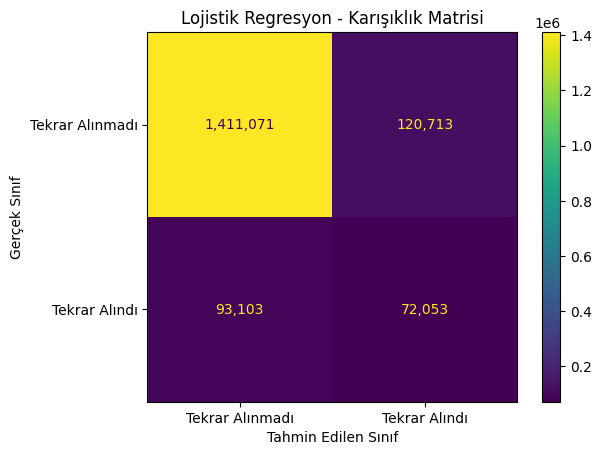

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tekrar Alınmadı", "Tekrar Alındı"]
)

disp.plot(values_format=",")

plt.title("Lojistik Regresyon - Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")

plt.show()

## Karışıklık Matrisi (Confusion Matrix) Yorumu

Karışıklık Matrisi (Confusion Matrix), modelin doğru ve yanlış tahminlerini dört farklı grupta göstermektedir.

Elde edilen sonuçlar:

- **True Negative (Doğru Negatif): 1.415.850**
  - Model, tekrar satın alınmayan ürünleri doğru şekilde "Tekrar Alınmadı" olarak tahmin etmiştir.

- **False Positive (Yanlış Pozitif): 122.585**
  - Ürün gerçekte tekrar satın alınmamış olmasına rağmen model "Tekrar Alındı" tahmini yapmıştır.

- **False Negative (Yanlış Negatif): 93.492**
  - Ürün gerçekte tekrar satın alınmış olmasına rağmen model bu satın alımı yakalayamamıştır.

- **True Positive (Doğru Pozitif): 72.637**
  - Model, gerçekten tekrar satın alınan ürünleri doğru şekilde "Tekrar Alındı" olarak tahmin etmiştir.

Model toplam **72.637 gerçek tekrar satın alma davranışını doğru şekilde yakalamıştır**.

Buna karşılık **93.492 tekrar satın alma davranışı model tarafından kaçırılmış**, **122.585 müşteri-ürün çifti ise yanlışlıkla tekrar satın alınacak olarak sınıflandırılmıştır**.

Bu sonuçlar, modelin pozitif sınıfı belirli ölçüde yakalayabildiğini ancak sınıf dengesizliği nedeniyle tekrar satın alma sınıfında hâlâ geliştirme alanı bulunduğunu göstermektedir.

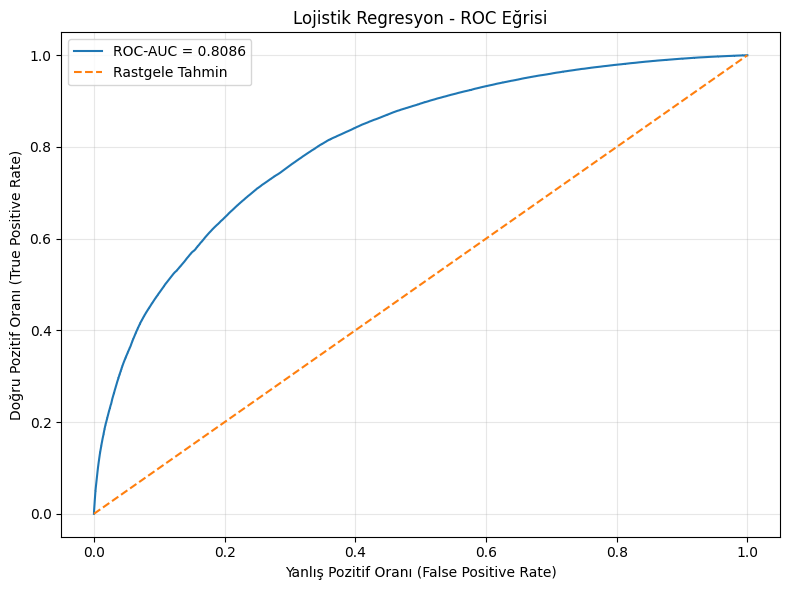

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Rastgele Tahmin"
)

plt.title("Lojistik Regresyon - ROC Eğrisi")
plt.xlabel("Yanlış Pozitif Oranı (False Positive Rate)")
plt.ylabel("Doğru Pozitif Oranı (True Positive Rate)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## ROC Eğrisi (Receiver Operating Characteristic Curve) Yorumu

ROC Eğrisi (Receiver Operating Characteristic Curve), modelin farklı sınıflandırma eşiklerinde pozitif ve negatif sınıfları birbirinden ne kadar iyi ayırabildiğini göstermektedir.

Grafikte yer alan kesikli çizgi rastgele tahmin seviyesini temsil etmektedir. Model eğrisinin bu çizginin belirgin şekilde üzerinde olması, modelin rastgele tahminden daha başarılı olduğunu göstermektedir.

Lojistik Regresyon (Logistic Regression) modeli için:

- **ROC-AUC (Receiver Operating Characteristic – Area Under the Curve): 0,8079**

olarak hesaplanmıştır.

ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) değerinin **0,80'in üzerinde olması**, modelin tekrar satın alınacak ve tekrar satın alınmayacak müşteri-ürün çiftlerini birbirinden ayırma gücünün iyi seviyede olduğunu göstermektedir.

ROC Eğrisi özellikle modelin genel ayırt etme performansını değerlendirmek açısından faydalıdır. Ancak hedef değişkende sınıf dengesizliği bulunduğu için model performansı yalnızca ROC-AUC üzerinden değerlendirilmemiştir.

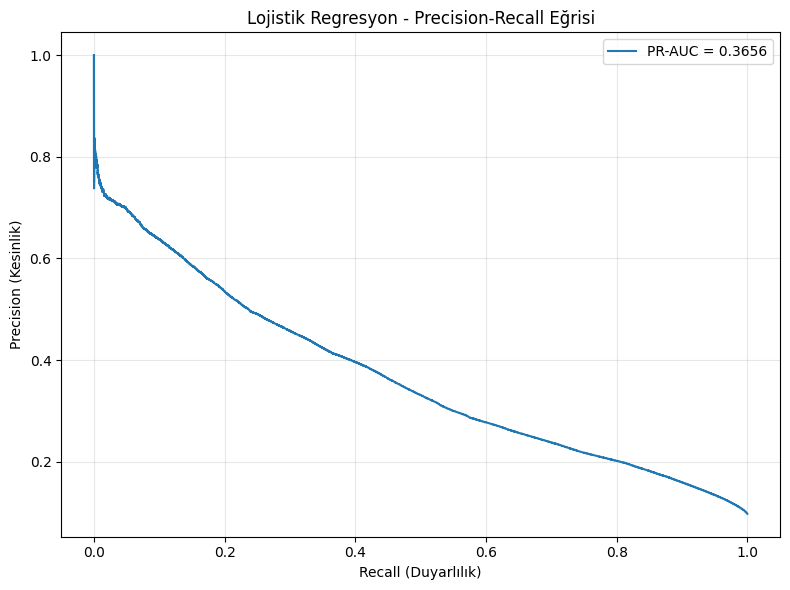

In [25]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.title("Lojistik Regresyon - Precision-Recall Eğrisi")
plt.xlabel("Recall (Duyarlılık)")
plt.ylabel("Precision (Kesinlik)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Precision-Recall Eğrisi Yorumu

Precision-Recall Eğrisi, özellikle hedef sınıfın dengesiz olduğu sınıflandırma problemlerinde model performansını değerlendirmek için önemli bir görselleştirmedir.

Bu grafik:

- **Precision (Kesinlik):** Modelin tekrar satın alınacağını tahmin ettiği ürünlerin ne kadarının gerçekten tekrar satın alındığını,
- **Recall (Duyarlılık):** Gerçekten tekrar satın alınan ürünlerin ne kadarının model tarafından yakalandığını

birlikte göstermektedir.

Lojistik Regresyon (Logistic Regression) modeli için:

- **PR-AUC (Precision-Recall – Area Under the Curve): 0,3643**

olarak hesaplanmıştır.

Hedef değişkende tekrar satın alma sınıfının oranı yaklaşık **%9,8** olduğu için veri setinde belirgin bir sınıf dengesizliği bulunmaktadır.

Bu nedenle PR-AUC (Precision-Recall – Area Under the Curve) metriği, modelin pozitif sınıfı ayırt etme performansını değerlendirmede Accuracy (Doğruluk) metriğine göre daha açıklayıcı bir ölçüt sağlamaktadır.

Modelin PR-AUC değerinin pozitif sınıfın yaklaşık %9,8 olan temel oranının belirgin şekilde üzerinde olması, tekrar satın alma davranışının model tarafından anlamlı ölçüde ayırt edilebildiğini göstermektedir.

In [26]:
coef_df = pd.DataFrame({
    "Değişken": features,
    "Standartlaştırılmış_Katsayı": log_model.coef_[0]
})

coef_df["Mutlak_Etki"] = coef_df["Standartlaştırılmış_Katsayı"].abs()

coef_df = coef_df.sort_values(
    "Mutlak_Etki",
    ascending=False
)

coef_df

,Değişken,Standartlaştırılmış_Katsayı,Mutlak_Etki
8,orders_since_last_purchase,-1.019567,1.019567
7,user_product_order_rate,0.708704,0.708704
5,total_prior_orders,-0.402040,0.402040
0,product_purchase_count,0.280370,0.280370
2,last_product_order,0.220528,0.220528
1,first_product_order,0.175549,0.175549
3,product_order_span,0.124141,0.124141
6,avg_days_between_orders,-0.051104,0.051104
4,avg_add_to_cart_order,0.003183,0.003183


## Lojistik Regresyon Katsayılarının Yorumlanması

Lojistik Regresyon (Logistic Regression) modelinde standartlaştırılmış katsayılar incelenerek, bağımsız değişkenlerin tekrar satın alma olasılığı üzerindeki yönü ve göreli etkisi değerlendirilmiştir.

Pozitif katsayılar, ilgili değişken arttıkça tekrar satın alma olasılığının artma eğiliminde olduğunu; negatif katsayılar ise tekrar satın alma olasılığının azalma eğiliminde olduğunu göstermektedir.

Öne çıkan değişkenler:

- `orders_since_last_purchase` katsayısı yaklaşık **-1,01** ile en güçlü negatif etkiye sahiptir. Bu sonuç, ürünün son satın alınmasından bu yana geçen sipariş sayısı arttıkça tekrar satın alma olasılığının azaldığını göstermektedir.

- `user_product_order_rate` katsayısı yaklaşık **+0,72** ile en güçlü pozitif etkilerden biridir. Müşterinin geçmiş siparişlerinde ilgili ürüne daha sık yer vermesi, tekrar satın alma olasılığını artırmaktadır.

- `total_prior_orders` katsayısı yaklaşık **-0,40** olup, diğer değişkenler sabit tutulduğunda müşterinin toplam geçmiş sipariş sayısının artmasının tekrar satın alma olasılığı üzerinde negatif yönlü bir etkisi bulunduğunu göstermektedir.

- `product_purchase_count` katsayısı yaklaşık **+0,27**'dir. Müşterinin ürünü geçmişte daha fazla kez satın alması, tekrar satın alma olasılığını artırmaktadır.

- `last_product_order` ve `first_product_order` değişkenleri de pozitif katsayılara sahiptir ve ürünün müşterinin sipariş geçmişindeki konumunun tekrar satın alma davranışıyla ilişkili olduğunu göstermektedir.

`avg_add_to_cart_order` değişkeninin katsayısının sıfıra çok yakın olması, bu değişkenin model üzerindeki etkisinin oldukça düşük olduğunu göstermektedir.

Değişkenler modelleme öncesinde standartlaştırıldığı için katsayıların mutlak büyüklükleri birbirleriyle daha sağlıklı şekilde karşılaştırılabilmektedir.

Bu katsayılar değişkenlerin model içerisindeki ilişkisini göstermektedir ve doğrudan nedensellik olarak yorumlanmamalıdır.

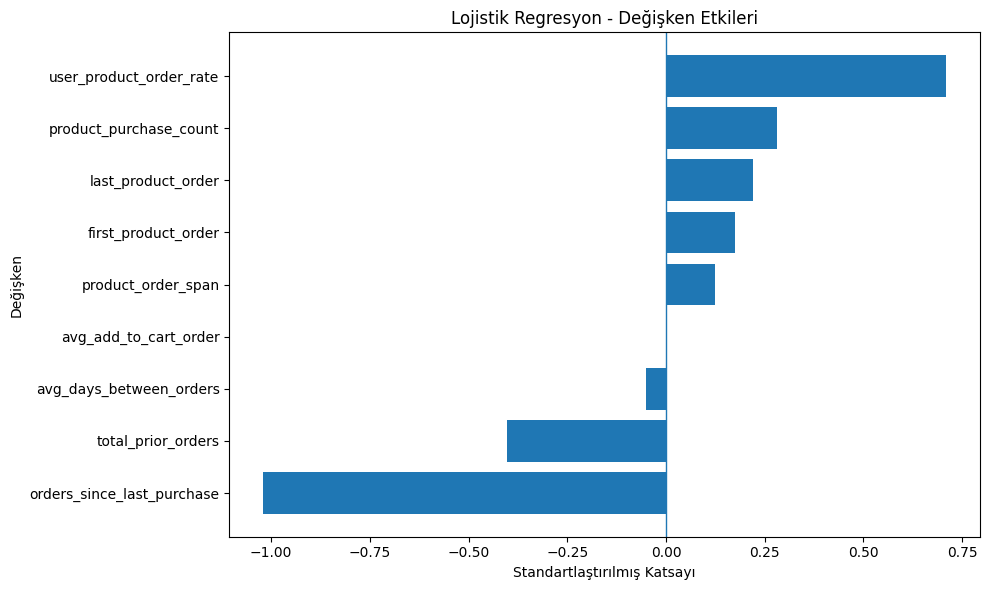

In [27]:
plot_coef = coef_df.sort_values("Standartlaştırılmış_Katsayı")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_coef["Değişken"],
    plot_coef["Standartlaştırılmış_Katsayı"]
)

plt.axvline(0, linewidth=1)

plt.title("Lojistik Regresyon - Değişken Etkileri")
plt.xlabel("Standartlaştırılmış Katsayı")
plt.ylabel("Değişken")

plt.tight_layout()
plt.show()

## Değişken Etkileri Grafiğinin Yorumu

Grafikte Lojistik Regresyon (Logistic Regression) modelinde kullanılan değişkenlerin standartlaştırılmış katsayıları gösterilmektedir.

Pozitif katsayılar tekrar satın alma olasılığını artıran, negatif katsayılar ise azaltan yöndeki ilişkileri göstermektedir.

Öne çıkan değişkenler:

- `user_product_order_rate` (**Müşteri-Ürün Sipariş Oranı**): Yaklaşık **+0,72** katsayı ile tekrar satın alma olasılığını artıran en güçlü değişkendir. Müşterinin geçmiş siparişlerinde ilgili ürüne daha sık yer vermesi, tekrar satın alma eğilimini artırmaktadır.

- `product_purchase_count` (**Ürünün Geçmiş Satın Alma Sayısı**): Yaklaşık **+0,27** katsayıya sahiptir. Müşterinin ürünü geçmişte daha fazla kez satın alması, tekrar satın alma olasılığıyla pozitif ilişkilidir.

- `last_product_order` (**Ürünün Son Görüldüğü Sipariş Numarası**): Yaklaşık **+0,22** katsayıya sahiptir. Ürünün müşterinin daha yakın dönem siparişlerinde yer alması tekrar satın alma olasılığıyla pozitif ilişki göstermektedir.

- `first_product_order` (**Ürünün İlk Görüldüğü Sipariş Numarası**): Yaklaşık **+0,17** katsayıya sahiptir.

- `product_order_span` (**Ürünün İlk ve Son Satın Alımı Arasındaki Sipariş Aralığı**): Yaklaşık **+0,13** katsayıyla pozitif yönlü ilişki göstermektedir.

- `avg_add_to_cart_order` (**Ortalama Sepete Ekleme Sırası**): Katsayısı sıfıra çok yakındır. Bu nedenle model üzerindeki etkisinin oldukça düşük olduğu görülmektedir.

- `avg_days_between_orders` (**Siparişler Arasındaki Ortalama Gün Sayısı**): Yaklaşık **-0,05** katsayıya sahiptir ve tekrar satın alma olasılığıyla zayıf negatif ilişki göstermektedir.

- `total_prior_orders` (**Toplam Geçmiş Sipariş Sayısı**): Yaklaşık **-0,40** katsayıyla negatif yönlü ilişki göstermektedir.

- `orders_since_last_purchase` (**Son Satın Alımdan Bu Yana Geçen Sipariş Sayısı**): Yaklaşık **-1,01** katsayı ile tekrar satın alma olasılığını azaltan en güçlü değişkendir. Ürünün son satın alınmasından sonra daha fazla sipariş geçtikçe, tekrar satın alınma olasılığı belirgin şekilde azalmaktadır.

### Genel Sonuç

Model açısından tekrar satın alma davranışını en güçlü şekilde açıklayan iki değişken:

1. **Son satın alımdan bu yana geçen sipariş sayısı**
2. **Müşterinin geçmiş siparişlerinde ilgili ürüne yer verme oranı**

olarak öne çıkmaktadır.

Bu sonuç, tekrar satın alma davranışında hem **ürünün ne kadar yakın zamanda satın alındığının** hem de **müşterinin o ürünü ne kadar düzenli satın aldığının** önemli olduğunu göstermektedir.

Katsayılar değişkenler arasındaki model içi ilişkileri göstermekte olup doğrudan nedensellik olarak yorumlanmamalıdır.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest (Rastgele Orman) modeli başarıyla eğitildi.")

Random Forest (Rastgele Orman) modeli başarıyla eğitildi.


## Karşılaştırma Modeli: Random Forest (Rastgele Orman)

Ana model olarak Lojistik Regresyon (Logistic Regression) kullanılmakla birlikte, model performansını karşılaştırmak amacıyla ikinci bir sınıflandırma modeli olarak Random Forest (Rastgele Orman) uygulanmıştır.

Random Forest (Rastgele Orman), birden fazla karar ağacının sonuçlarını bir araya getirerek sınıflandırma yapan bir makine öğrenmesi yöntemidir.

Bu modelin kullanılma amacı, Lojistik Regresyon (Logistic Regression) modelinin performansını farklı bir algoritmayla karşılaştırmak ve ana model seçimini daha sağlam bir temele dayandırmaktır.

Random Forest (Rastgele Orman) modeli ağaç tabanlı bir yöntem olduğu için değişkenlerin standartlaştırılması zorunlu değildir. Bu nedenle model, standartlaştırılmamış `X_train` verisi kullanılarak eğitilmiştir.

Projenin ana modeli Lojistik Regresyon (Logistic Regression) olmaya devam edecektir. Random Forest (Rastgele Orman) yalnızca karşılaştırma amacıyla kullanılacaktır.

In [29]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest tahmin işlemi tamamlandı.")
print("Tahmin edilen sınıf sayısı:", len(rf_pred))
print("Tahmin edilen olasılık sayısı:", len(rf_prob))

Random Forest tahmin işlemi tamamlandı.
Tahmin edilen sınıf sayısı: 1696940
Tahmin edilen olasılık sayısı: 1696940


## Random Forest Test Tahminlerinin Oluşturulması

Random Forest (Rastgele Orman) modeli eğitildikten sonra test verisi üzerinde sınıf ve olasılık tahminleri üretilmiştir.

Bu aşamada iki farklı çıktı oluşturulmuştur:

- `rf_pred`: Random Forest (Rastgele Orman) modelinin her müşteri-ürün çifti için verdiği sınıf tahminidir.
  - **0:** Ürün tekrar satın alınmadı.
  - **1:** Ürün tekrar satın alındı.

- `rf_prob`: Her müşteri-ürün çifti için model tarafından hesaplanan tekrar satın alma olasılığıdır.

Bu tahminler, Random Forest (Rastgele Orman) modelinin performans metriklerinin hesaplanmasında ve Lojistik Regresyon (Logistic Regression) modeli ile karşılaştırılmasında kullanılacaktır.

In [30]:
print("Lojistik Regresyon tahmin sayısı:", len(y_pred))
print("Random Forest tahmin sayısı:", len(rf_pred))
print("Gerçek test hedef sayısı:", len(y_test))

Lojistik Regresyon tahmin sayısı: 1696940
Random Forest tahmin sayısı: 1696940
Gerçek test hedef sayısı: 1696940


In [31]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

model_comparison = pd.DataFrame({
    "Model": [
        "Lojistik Regresyon",
        "Random Forest"
    ],
    "Accuracy (Doğruluk)": [
        accuracy,
        rf_accuracy
    ],
    "Precision (Kesinlik)": [
        precision,
        rf_precision
    ],
    "Recall (Duyarlılık)": [
        recall,
        rf_recall
    ],
    "F1 Score (F1 Skoru)": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ],
    "PR-AUC": [
        pr_auc,
        rf_pr_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy (Doğruluk),Precision (Kesinlik),Recall (Duyarlılık),F1 Score (F1 Skoru),ROC-AUC,PR-AUC
0,Lojistik Regresyon,0.8740,0.3738,0.4363,0.4026,0.8086,0.3656
1,Random Forest,0.8599,0.3523,0.5244,0.4215,0.8197,0.3976


## Model Karşılaştırması ve Model Seçimi

Lojistik Regresyon (Logistic Regression) ve Random Forest (Rastgele Orman) modelleri aynı test veri seti üzerinde karşılaştırılmıştır.

Random Forest modeli Recall (Duyarlılık), F1 Score (F1 Skoru), ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) ve PR-AUC (Precision-Recall – Area Under the Curve) metriklerinde Lojistik Regresyon modelinden bir miktar daha yüksek performans göstermiştir.

Buna karşılık Lojistik Regresyon modeli Accuracy (Doğruluk) ve Precision (Kesinlik) metriklerinde daha yüksek sonuç üretmiştir.

İki model arasındaki performans farkının sınırlı olması ve Lojistik Regresyon modelinin katsayılar üzerinden daha kolay yorumlanabilmesi nedeniyle projenin ana modeli olarak **Lojistik Regresyon (Logistic Regression)** seçilmiştir.

Lojistik Regresyon sayesinde yalnızca tahmin üretmek değil, müşterinin tekrar satın alma davranışını etkileyen değişkenlerin yönünü ve göreli etkisini de açıklamak mümkün olmuştur.

## Nihai İş Çıkarımları

1. **Ürünün ne kadar yakın zamanda satın alındığı tekrar satın alma açısından en önemli göstergelerden biridir.** Son satın alımdan sonra geçen sipariş sayısı arttıkça tekrar satın alma olasılığı belirgin şekilde azalmaktadır.

2. **Müşterinin bir ürünü geçmiş siparişlerinde düzenli olarak satın alması tekrar satın alma ihtimalini artırmaktadır.** `user_product_order_rate` (Müşteri-Ürün Sipariş Oranı) modelde en güçlü pozitif değişkenlerden biridir.

3. **Geçmiş satın alma sıklığı önemlidir.** Bir ürünün müşteri tarafından daha önce birden fazla kez satın alınmış olması gelecekte yeniden satın alınma ihtimalini artırmaktadır.

4. Model, müşteri-ürün çiftleri için yalnızca 0 veya 1 sınıfı üretmekle kalmayıp aynı zamanda **tekrar satın alma olasılığı** da üretebilmektedir. Bu olasılık müşteriye özel ürün önerilerinde kullanılabilir.

5. Model sonuçları; kişiselleştirilmiş ürün önerileri, yeniden satın alma hatırlatmaları, CRM kampanyaları ve müşteriye özel iletişim stratejilerinin geliştirilmesinde kullanılabilir.

In [32]:
prediction_results = test_df[["user_id", "product_id"]].copy()

prediction_results["actual_reorder"] = y_test.values
prediction_results["predicted_reorder"] = y_pred
prediction_results["reorder_probability"] = y_prob

print("Toplam tahmin edilen müşteri-ürün çifti:", len(prediction_results))

print(
    "Tekrar satın alacağı tahmin edilen müşteri-ürün çifti:",
    prediction_results["predicted_reorder"].sum()
)

print(
    "Gerçekte tekrar satın alınan müşteri-ürün çifti:",
    prediction_results["actual_reorder"].sum()
)

prediction_results.head()

Toplam tahmin edilen müşteri-ürün çifti: 1696940
Tekrar satın alacağı tahmin edilen müşteri-ürün çifti: 192766.0
Gerçekte tekrar satın alınan müşteri-ürün çifti: 165156


,user_id,product_id,actual_reorder,predicted_reorder,reorder_probability
8,10660,38266,0,0.0,0.000044
18,201743,20119,0,0.0,0.000309
24,137216,13554,0,0.0,0.000467
25,4363,47766,0,0.0,0.000515
32,63849,21614,1,0.0,0.000857


## Tekrar Satın Alma Tahminlerinin Sayısal Özeti

Lojistik Regresyon (Logistic Regression) modeli kullanılarak test veri setindeki müşteri-ürün çiftleri için tekrar satın alma tahminleri üretilmiştir.

Model toplam **1.696.940 müşteri-ürün çifti** için tahmin oluşturmuştur.

Elde edilen sonuçlara göre:

- Model **192.688 müşteri-ürün çiftini** tekrar satın alma adayı olarak sınıflandırmıştır.
- Test veri setinde gerçekte tekrar satın alınan müşteri-ürün çifti sayısı **165.156**'dır.

Model, yalnızca 0 veya 1 sınıf tahmini üretmemekte, aynı zamanda her müşteri-ürün çifti için `reorder_probability` (**Tekrar Satın Alma Olasılığı**) değeri de hesaplamaktadır.

Bu olasılık değerleri sayesinde müşteri bazında tekrar satın alma ihtimali en yüksek ürünler sıralanabilir ve kişiselleştirilmiş ürün önerileri oluşturulabilir.

Modelin tekrar satın alma adayı olarak işaretlediği kayıt sayısının gerçek tekrar satın alma sayısından daha yüksek olması, modelin bazı müşteri-ürün çiftlerini yanlış pozitif olarak sınıflandırdığını göstermektedir. Bu durum daha önce hesaplanan Precision (Kesinlik) metriği ile de uyumludur.

In [33]:
top_reorder_predictions = (
    prediction_results
    .sort_values("reorder_probability", ascending=False)
    .head(20)
)

top_reorder_predictions

,user_id,product_id,actual_reorder,predicted_reorder,reorder_probability
7151903,123746,1160,1,1.0,0.999706
1866954,36335,11784,1,1.0,0.999702
7282480,75124,8061,1,1.0,0.999642
5701093,75124,11925,1,1.0,0.999642
8381095,75124,18926,1,1.0,0.999642
5622403,75124,4957,1,1.0,0.999642
7573240,75124,22124,1,1.0,0.999642
7586405,75124,24954,1,1.0,0.999642
4412954,75124,40571,1,1.0,0.999642
1791178,75124,19156,1,1.0,0.999607


## En Yüksek Tekrar Satın Alma Olasılığına Sahip Tahminler

Lojistik Regresyon (Logistic Regression) modeli tarafından her müşteri-ürün çifti için `reorder_probability` (**Tekrar Satın Alma Olasılığı**) değeri hesaplanmıştır.

Bu aşamada, tekrar satın alma olasılığı en yüksek olan ilk **20 müşteri-ürün çifti** sıralanmıştır.

Tabloda yer alan alanlar:

- `user_id` (**Müşteri Kimliği**): Müşteriyi temsil eden benzersiz kimlik numarasıdır.
- `product_id` (**Ürün Kimliği**): Ürünü temsil eden benzersiz kimlik numarasıdır.
- `actual_reorder` (**Gerçek Tekrar Satın Alma Durumu**): Ürünün gerçekten tekrar satın alınıp alınmadığını gösterir.
- `predicted_reorder` (**Tahmin Edilen Tekrar Satın Alma Durumu**): Modelin 0 veya 1 olarak verdiği sınıf tahminidir.
- `reorder_probability` (**Tekrar Satın Alma Olasılığı**): Modelin ilgili müşteri-ürün çifti için hesapladığı tekrar satın alma olasılığıdır.

En yüksek olasılıklı müşteri-ürün çiftlerinde `reorder_probability` değerlerinin **%99'un üzerinde** olduğu görülmektedir.

Bu çıktı, model sonuçlarının müşteri bazında sıralanarak kişiselleştirilmiş ürün önerileri oluşturmak amacıyla kullanılabileceğini göstermektedir.

In [34]:
query_products = """
SELECT
  product_id,
  product_name,
  aisle_name,
  department_name
FROM `project-84485539-b01a-418a-932.Instacart_Analytics.dim_products`
"""

products_df = client.query(query_products).to_dataframe()

top_reorder_enriched = top_reorder_predictions.merge(
    products_df,
    on="product_id",
    how="left"
)

top_reorder_enriched[
    [
        "user_id",
        "product_id",
        "product_name",
        "aisle_name",
        "department_name",
        "actual_reorder",
        "predicted_reorder",
        "reorder_probability"
    ]
]

,user_id,product_id,product_name,aisle_name,department_name,actual_reorder,predicted_reorder,reorder_probability
0,123746,1160,Pinot Grigio,white wines,alcohol,1,1.0,0.999706
1,36335,11784,Duck Eggs,eggs,dairy eggs,1,1.0,0.999702
2,75124,8061,Pineapple Yogurt 2%,yogurt,dairy eggs,1,1.0,0.999642
3,75124,11925,Total 2% with Raspberry Pomegranate Lowfat Gre...,yogurt,dairy eggs,1,1.0,0.999642
4,75124,18926,Fat Free Strawberry Yogurt,yogurt,dairy eggs,1,1.0,0.999642
5,75124,4957,Total 2% Lowfat Greek Strained Yogurt With Blu...,yogurt,dairy eggs,1,1.0,0.999642
6,75124,22124,Total 0% Raspberry Yogurt,yogurt,dairy eggs,1,1.0,0.999642
7,75124,24954,Total 0% with Honey Nonfat Greek Strained Yogurt,yogurt,dairy eggs,1,1.0,0.999642
8,75124,40571,Total 2% Greek Strained Yogurt with Cherry 5.3 oz,yogurt,dairy eggs,1,1.0,0.999642
9,75124,19156,Fat Free Blueberry Yogurt,yogurt,dairy eggs,1,1.0,0.999607


## Ürün Bilgileri ile Tahmin Sonuçlarının Zenginleştirilmesi

Model tarafından üretilen tekrar satın alma tahminlerini daha anlaşılır hale getirmek amacıyla ürün kimlikleri (`product_id`) ürün detaylarıyla eşleştirilmiştir.

BigQuery üzerinde bulunan `dim_products` tablosu kullanılarak tahmin sonuçlarına aşağıdaki bilgiler eklenmiştir:

- `product_name` (**Ürün Adı**)
- `aisle_name` (**Reyon Adı**)
- `department_name` (**Departman Adı**)

Böylece model çıktıları yalnızca ürün kimliği üzerinden değil, doğrudan ürün ve kategori bilgileri üzerinden yorumlanabilir hale getirilmiştir.

En yüksek tekrar satın alma olasılığına sahip kayıtlar incelendiğinde yoğurt, yumurta, meyve ve benzeri sık tüketilen ürünlerin öne çıktığı görülmektedir.

Bazı müşteri-ürün çiftlerinde `reorder_probability` (**Tekrar Satın Alma Olasılığı**) %99'un üzerinde olmasına rağmen `actual_reorder` (**Gerçek Tekrar Satın Alma Durumu**) değerinin 0 olduğu örnekler de bulunmaktadır.

Bu durum, yüksek tahmin olasılığının her zaman gerçek satın alma ile sonuçlanmadığını ve model sonuçlarının olasılıksal tahminler olarak değerlendirilmesi gerektiğini göstermektedir.

In [35]:
department_reorder_summary = (
    top_reorder_enriched
    .groupby("department_name")
    .agg(
        tahmin_sayisi=("predicted_reorder", "count"),
        ortalama_tekrar_satin_alma_olasiligi=("reorder_probability", "mean")
    )
    .sort_values("tahmin_sayisi", ascending=False)
)

department_reorder_summary

,tahmin_sayisi,ortalama_tekrar_satin_alma_olasiligi
department_name,,
dairy eggs,15,0.999518
produce,3,0.999204
alcohol,1,0.999706
snacks,1,0.999174


## Departman Bazlı Kısa Değerlendirme

En yüksek tekrar satın alma olasılığına sahip ilk 20 müşteri-ürün çifti departman bazında incelendiğinde:

- `dairy eggs` (**Süt Ürünleri ve Yumurta**) departmanı 15 kayıt ile açık ara öne çıkmaktadır.
- `produce` (**Meyve ve Sebze**) departmanında 3 kayıt bulunmaktadır.
- `alcohol` (**Alkollü İçecekler**) ve `snacks` (**Atıştırmalıklar**) departmanlarında 1'er kayıt bulunmaktadır.

Bu sonuç, yüksek tekrar satın alma olasılığına sahip örneklerde özellikle düzenli tüketilen gıda ürünlerinin öne çıktığını göstermektedir.

Ancak bu analiz yalnızca en yüksek olasılıklı ilk 20 tahmini kapsadığı için tüm veri setinin departman dağılımını temsil ettiği şeklinde yorumlanmamalıdır.

# Proje Sonucu

Bu projede Instacart müşterilerinin geçmiş sipariş davranışları kullanılarak bir müşterinin daha önce satın aldığı bir ürünü tekrar satın alıp almayacağı tahmin edilmiştir.

Ana model olarak **Lojistik Regresyon (Logistic Regression)** kullanılmış, karşılaştırma amacıyla **Random Forest (Rastgele Orman)** modeli de çalıştırılmıştır.

Lojistik Regresyon modeli:

- **Accuracy (Doğruluk): %87,40**
- **Precision (Kesinlik): %37,38**
- **Recall (Duyarlılık): %43,61**
- **F1 Score (F1 Skoru): 0,4026**
- **ROC-AUC (Receiver Operating Characteristic – Area Under the Curve): 0,8086**
- **PR-AUC (Precision-Recall – Area Under the Curve): 0,3655**

performansı göstermiştir.

Random Forest (Rastgele Orman) bazı değerlendirme metriklerinde daha yüksek sonuç üretmesine rağmen, performans farkının sınırlı kalması ve Lojistik Regresyon (Logistic Regression) modelinin daha yüksek açıklanabilirlik sağlaması nedeniyle ana model olarak Lojistik Regresyon tercih edilmiştir.

Analiz sonucunda tekrar satın alma davranışında özellikle:

- ürünün son satın alınmasından bu yana geçen sipariş sayısının,
- müşterinin ilgili ürünü geçmiş siparişlerinde ne kadar düzenli satın aldığının,
- ürünün geçmiş satın alma sıklığının

önemli göstergeler olduğu görülmüştür.

Model, test veri setindeki yaklaşık **1,70 milyon müşteri-ürün çifti** için tekrar satın alma olasılığı üretmiş ve **192.688 müşteri-ürün çiftini tekrar satın alma adayı** olarak sınıflandırmıştır.

Elde edilen tahminler; kişiselleştirilmiş ürün önerileri, tekrar satın alma hatırlatmaları, CRM kampanyaları ve müşteriye özel iletişim stratejilerinde kullanılabilecek bir karar destek çıktısı sunmaktadır.